Load the healthcare dataset from a CSV file into a pandas DataFrame and display the first few rows to inspect the data structure and column names.

In [71]:
import pandas as pd
df =pd.read_csv('C:\\Users\\amira\\Downloads\\healthcare.csv')
df.head()

,HeartRate,BloodPressure
0,52.483571,31.877002
1,49.308678,27.428527
2,53.238443,26.787323
3,57.615149,31.447417
4,48.829233,29.329612


Create a scatter plot of HeartRate vs BloodPressure to visually inspect patterns, trends, or potential outliers in the data.

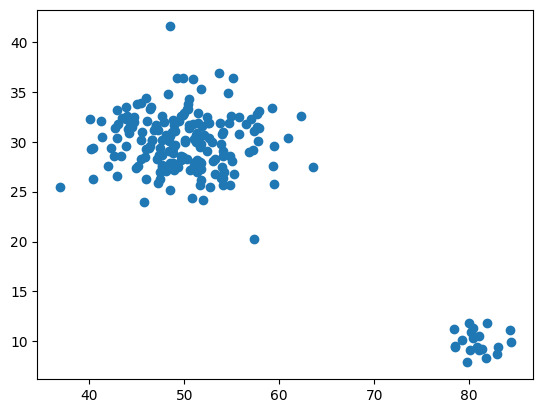

In [72]:
import matplotlib.pyplot as plt
plt.scatter(df['HeartRate'], df['BloodPressure'])

In [73]:
from sklearn.ensemble import IsolationForest

Use Isolation Forest to detect anomalies in the dataset. The contamination parameter specifies the proportion of expected outliers. Each row is labeled as 1 (normal) or -1 (anomaly) and stored in a new column pred.

In [74]:

 
clf = IsolationForest(contamination=0.1,
                      n_estimators=200,
                      max_samples='auto',
                      random_state=42)
preds = clf.fit_predict(df)  # preds:  1 (normal) or -1 (anomaly)
df['pred'] = preds


Display the predicted labels from the Isolation Forest to see which rows are considered normal or anomalous.

In [75]:
preds

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1,  1,  1, -1,  1,
       -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

Identify the indices of the data points classified as anomalies by the Isolation Forest.

In [76]:
import numpy as np

abn_id = np.where (preds < 0)
abn_id

(array([ 29,  74,  82, 113, 179, 181, 182, 185, 187, 189, 190, 191, 192,
        193, 194, 195, 196, 197, 198, 199]),)

In [77]:
x = df.values

Create a scatter plot where normal points are blue and anomalies are highlighted in red. This helps visually compare the anomalies detected by Isolation Forest.

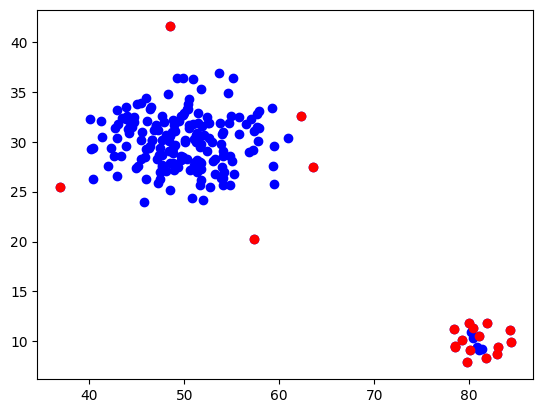

In [78]:
abn_id = np.where(preds < 0)
plt.scatter(df.iloc[:,0], df.iloc[:,1], c='blue')
plt.scatter(x[abn_id,0], x[abn_id,1], c='red')

Generate a synthetic "circles" dataset for demonstration purposes and plot the points colored by their original class labels. This is useful to test clustering algorithms like DBSCAN

In [79]:
from sklearn.cluster import DBSCAN
#from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import make_circles

In [80]:
x,y = make_circles(n_samples= 750, factor= 0.3, noise= 0.1)

In [81]:
x

array([[-0.4643718 , -0.08855507],
       [ 0.71090348, -0.40490111],
       [-0.27978451, -0.24703157],
       ...,
       [-0.22551123, -0.23946926],
       [-0.35146058,  0.75189512],
       [ 0.13197933, -0.10039036]], shape=(750, 2))

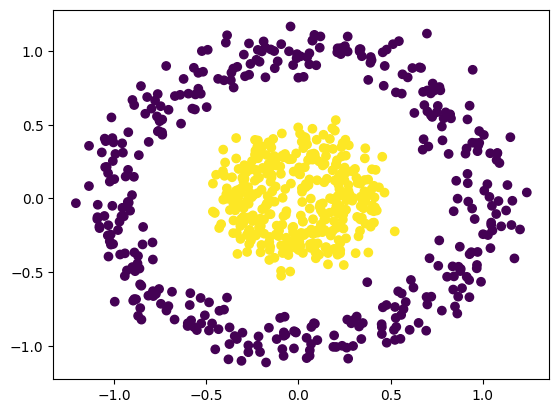

In [82]:
plt.scatter(x[:,0], x[:,1], c=y)

In [83]:
from sklearn.cluster import DBSCAN

In [84]:
dbcan = DBSCAN(eps =0.10)

In [85]:
dbcan.fit_predict(x)

array([ 0, -1,  0,  0, -1,  0,  1,  3,  2,  2,  3,  0,  0,  3,  0,  0,  0,
        0, -1,  0,  0,  0,  7,  4,  5,  2,  3,  0,  6,  0,  1,  3,  0,  4,
        3,  0,  3,  0,  1,  0,  2,  7,  0,  6,  3,  0,  3,  3,  0, -1,  0,
        0, -1,  0,  0,  3,  0,  8,  3,  3,  9,  0,  0,  2,  0,  0, 10,  0,
        0,  2,  3,  4,  0,  9,  3,  3,  2,  0,  0,  4,  0,  3,  8,  2,  2,
        0,  0,  0,  4,  9,  0,  0,  0,  3, -1, -1, -1,  0,  7,  3, -1,  1,
        3,  0,  0,  0,  4,  0,  0,  8,  3,  3,  0,  0,  0,  1,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  3,  0,  2,  9,  0,  2,  0,  2,  0,  0,  6,
        0,  2,  0,  3,  0,  3,  0,  2,  2,  0,  3,  0,  2,  0, -1,  3,  0,
        0,  3,  7,  9,  0,  0,  3,  5,  1,  0,  3,  3,  3,  0,  0,  0,  0,
        2,  0,  0,  8,  0,  0,  0,  0,  0,  2,  0,  3,  0,  4,  3,  6,  0,
        7,  0,  0,  0,  0, 11,  0,  5,  0,  0,  0,  3, -1, -1,  0,  3,  0,
        0,  2,  0,  7,  8,  3,  0,  0, -1,  0,  0,  0,  8,  0,  0,  1,  0,
        0,  3,  0,  0, -1

In [86]:
dbcan.labels_

array([ 0, -1,  0,  0, -1,  0,  1,  3,  2,  2,  3,  0,  0,  3,  0,  0,  0,
        0, -1,  0,  0,  0,  7,  4,  5,  2,  3,  0,  6,  0,  1,  3,  0,  4,
        3,  0,  3,  0,  1,  0,  2,  7,  0,  6,  3,  0,  3,  3,  0, -1,  0,
        0, -1,  0,  0,  3,  0,  8,  3,  3,  9,  0,  0,  2,  0,  0, 10,  0,
        0,  2,  3,  4,  0,  9,  3,  3,  2,  0,  0,  4,  0,  3,  8,  2,  2,
        0,  0,  0,  4,  9,  0,  0,  0,  3, -1, -1, -1,  0,  7,  3, -1,  1,
        3,  0,  0,  0,  4,  0,  0,  8,  3,  3,  0,  0,  0,  1,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  3,  0,  2,  9,  0,  2,  0,  2,  0,  0,  6,
        0,  2,  0,  3,  0,  3,  0,  2,  2,  0,  3,  0,  2,  0, -1,  3,  0,
        0,  3,  7,  9,  0,  0,  3,  5,  1,  0,  3,  3,  3,  0,  0,  0,  0,
        2,  0,  0,  8,  0,  0,  0,  0,  0,  2,  0,  3,  0,  4,  3,  6,  0,
        7,  0,  0,  0,  0, 11,  0,  5,  0,  0,  0,  3, -1, -1,  0,  3,  0,
        0,  2,  0,  7,  8,  3,  0,  0, -1,  0,  0,  0,  8,  0,  0,  1,  0,
        0,  3,  0,  0, -1

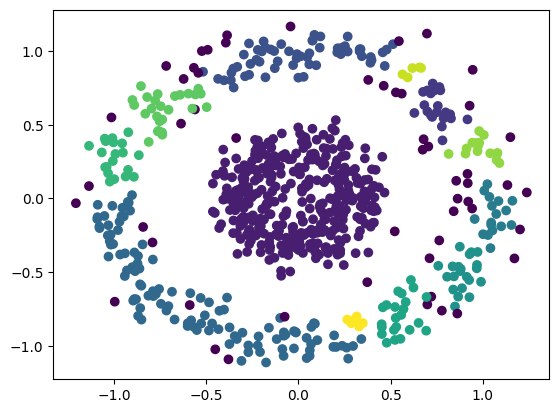

In [87]:
plt.scatter(x[:,0], x[:,1], c=dbcan.labels_)

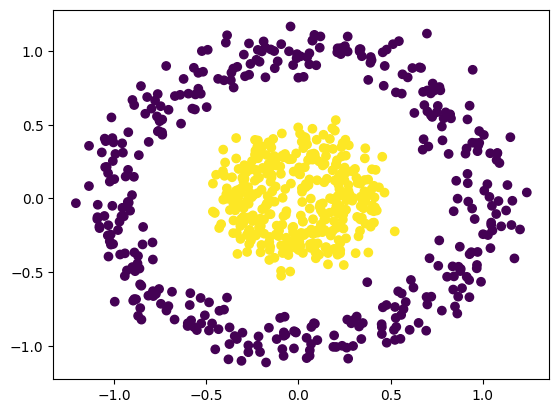

In [88]:
plt.scatter(x[:,0], x[:,1], c=y)

Scale the numeric features (HeartRate and BloodPressure) using StandardScaler so that DBSCAN clustering is not biased by differing feature scales.

In [89]:
from sklearn.preprocessing import StandardScaler
X = df[['HeartRate', 'BloodPressure']].values
X_scaled = StandardScaler().fit_transform(X)


Apply DBSCAN clustering to the scaled healthcare features. Cluster labels are added to the DataFrame. A scatter plot visualizes the clusters, with points labeled -1 considered noise or outliers. This helps identify natural groupings in the data as well as unusual cases.

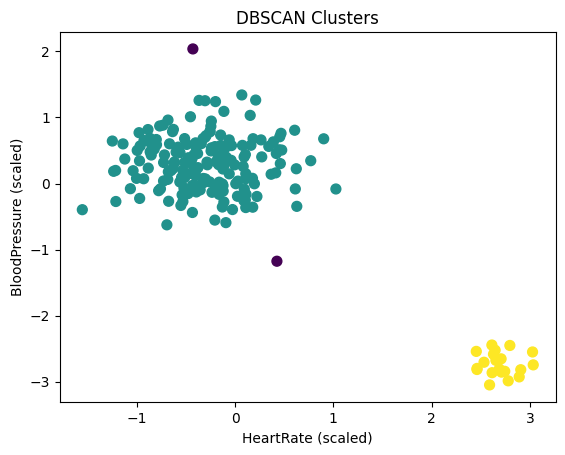

In [90]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Use only numeric features
X = df[['HeartRate', 'BloodPressure']].values
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  # you may need to tune eps
clusters = dbscan.fit_predict(X_scaled)

# Add cluster labels to the dataframe
df['cluster'] = clusters

# Plot
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap='viridis', s=50)
plt.xlabel('HeartRate (scaled)')
plt.ylabel('BloodPressure (scaled)')
plt.title('DBSCAN Clusters')
plt.show()
